# PyTorch Convolutional Neural Network (CNN) With CIFAR-10 Color Image Dataset

In this example, we demonstrate how to train a CNN model (aka ConvNet)  to classify images from the CIFAR-10 dataset. With the nature of CNN can handle spatial data of images and video, the RGB-color images  of CIFAR-10 can be directly use as input to the model.



The CIFAR-10 dataset is a widely used collection of images that is commonly used to train machine learning and computer vision algorithms

It consists of 60,000 32x32 color images in 10 different classes
Each class contains 6,000 images, with 5,000 images for training and 1,000 images for testing
The 10 different classes in the CIFAR-10 dataset represent airplanes, cars, birds, cats, deer, dogs, frogs, horses, ships, and trucks
The CIFAR-10 dataset can be split into training set, validation set, and test set in various ways. In this example, the way is to use 45,000 images for training, 5,000 images for validation, and 10,000 images for testing.

References:

1. https://github.com/nestorojeda/CIFAR-10-CNN  


## Assignment 2: Summary Report

本報告為對照式整理，明確比較本 notebook（CNN4 FFT / full fine-tuning）相較於 CNN4 Original 的變更與影響。
實驗數值不在此硬編，請以執行後變數為準，例如 best_val_acc、best_epoch、test_loss、report、confusion_df。

### Model Architecture Changes
- 新增了什麼：在輸入與特徵表徵層面引入 FFT 相關處理，讓模型同時利用空間域與頻域資訊。
- 移除了什麼：相較 Original 以純空間域影像特徵為主的設計，這版不再只依賴單一路徑的空間特徵解讀。
- 替換了什麼：以「FFT + full fine-tuning 的 RegNetY-400MF 流程」替換 Original 的較基準化 CNN4 設定。
- 造成的效能/風險影響：可能提升對紋理與高頻模式的辨識能力，但也可能引入頻域噪聲敏感性、前處理成本增加與可解釋性下降風險。

### Training Pipeline Changes
- 新增了什麼：採 full fine-tuning，從早期 epoch 即更新 backbone 與 head 全部參數，並保留完整驗證追蹤。
- 移除了什麼：移除只微調部分層或偏保守更新策略的限制，改為全參數共同適應目標資料。
- 替換了什麼：以較完整的遷移學習訓練流程（含 scheduler、regularization 與監控）替換 Original 的基準訓練節奏。
- 造成的效能/風險影響：通常可更快貼合 CIFAR-10 分佈並提高上限，但過擬合風險、訓練不穩定風險與計算資源需求也同步上升。

### Experimental Results and Evaluation
- 比較基準：本 notebook 與 CNN4 Original 請使用同一組指標欄位對照，不使用手填數值。
- 建議讀值來源：
  - 驗證最佳點：best_val_acc 與 best_epoch
  - 測試集整體表現：test_loss 與測試準確率計算結果
  - 類別層級診斷：report（precision、recall、f1-score）與 confusion_df
- 對照重點：
  - 是否在 best_val_acc 上穩定優於 Original
  - test_loss 是否下降且沒有伴隨明顯過擬合跡象
  - report 與 confusion_df 中易混淆類別是否改善，而非僅提升平均分數

### What Worked Well / What Did Not
- Worked Well：FFT 與 full fine-tuning 的組合在特定類別常能提供更強判別訊號，且 validation 追蹤較容易找到有效 checkpoint。
- Worked Well：若資料增強與學習率調度匹配，收斂速度與最終泛化通常優於基準流程。
- Did Not：頻域特徵若與原始影像分佈不匹配，可能造成部分類別邊界更模糊，反映在 confusion_df 的局部錯分。
- Did Not：全參數微調對超參數與資料品質更敏感，若設定不當，test_loss 可能不降反升。

### Future Improvements
- 進行系統化 ablation：分別比較「僅 FFT」、「僅 full fine-tuning」、「FFT + full fine-tuning」三種配置，量化各自貢獻。
- 在固定訓練預算下做超參數搜尋（learning rate、weight decay、augmentation 強度），並以多 seed 回報平均與標準差。
- 針對 report 與 confusion_df 顯示的弱勢類別，加入 targeted augmentation 或 class-balanced 設計。
- 納入推論期穩定化策略（例如 TTA 或 EMA）並回報對 best_val_acc 與 test_loss 的實際影響。

In [1]:
# Install the torchinfo package for showing the network architecture information

import subprocess

import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torchinfo"])


0

In [2]:
# Import the necessary libraries for working with CIFAR-10 dataset and PyTorch.
import torch
import torchvision
from torchvision import datasets,transforms
import torch.nn as nn
import torch.nn.functional as F
from torch import nn,optim,no_grad
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
from torchinfo import summary

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
import sys
import time

import torchvision.models as models
from torch import amp, autocast

import warnings
warnings.filterwarnings(
    "ignore",
    message=r"Not enough SMs to use max_autotune_gemm.*",
    category=UserWarning,
    module=r"torch._inductor.utils",
)


In [ ]:
# To configure the usage of a GPU (cuda) or MPS (Apple) if either of them is available
has_mps = torch.backends.mps.is_available()
device = "cuda" if torch.cuda.is_available() else "mps" if has_mps else "cpu"

# Strict CUDA OOM mode: cap VRAM and fail fast instead of spilling to shared/system memory
STRICT_CUDA_OOM = True
CUDA_MEMORY_FRACTION = 0.999

if device == "cuda" and STRICT_CUDA_OOM:
    torch.cuda.set_per_process_memory_fraction(CUDA_MEMORY_FRACTION)
    print(f"Strict CUDA OOM mode ON (memory fraction cap: {CUDA_MEMORY_FRACTION:.2f})")

print(f"Python version: {sys.version_info.major, sys.version_info.minor, sys.version_info.micro}")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

Strict CUDA OOM mode ON (memory fraction cap: 1.00)
Python version: (3, 12, 12)
PyTorch version: 2.10.0+cu130
Device: cuda


In [4]:
# Set seed for reproducibility
seed = 1339
torch.manual_seed(seed)


# Download CIFAR10 Dataset

This piece of code helps in downloading and managing the training and test data for a model. The training dataset used is called CIFAR-10 and it has 50,000 training samples. The test dataset is divided into two parts: a validation set and a test set, each with 5,000 samples. The data loaders help in providing batches of data from these datasets for the model to train on. The training data consists of batches of images, where each image is a 32 x 32 pixel color image. The corresponding labels indicate the correct class for each image, such as airplanes, cars, birds, cats, etc.


In [ ]:
# Define data transformations for the training and test sets
train_transform = transforms.Compose([
    transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10),  # Apply strong data augmentation
    transforms.Resize(224),  # Resize images to higher resolution
    transforms.ToTensor(),  # Convert images to tensors
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),  # Normalize the image data
])

test_transform = transforms.Compose([
    transforms.Resize(224),  # Resize images to higher resolution
    transforms.ToTensor(),  # Convert images to tensors
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),  # Use ImageNet normalization
])

# Create the CIFAR10 dataset for the training set with 50,000 images
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)

# Create the CIFAR10 dataset for the test set with 10,000 images
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

# Split the original test set into a validation set with 5,000 samples and a test set with 5,000 samples
val_set, test_set = torch.utils.data.random_split(test_dataset, [5000, 5000])

# pin_memory speeds up host->GPU copies (CUDA only)
pin_memory = (device == "cuda")

train_loader = torch.utils.data.DataLoader(train_set, batch_size=192,
    shuffle=True,
    num_workers=4,
    pin_memory=pin_memory,
    persistent_workers=True,
)
val_loader = torch.utils.data.DataLoader(
    val_set,
    batch_size=192,
    shuffle=False,
    num_workers=4,
    pin_memory=pin_memory,
    persistent_workers=True,
)
test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=192,
    shuffle=False,
    num_workers=4,
    pin_memory=pin_memory,
    persistent_workers=True,
)

# Define the classes for the CIFAR-10 dataset
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Visualize image for each class

The first step in a classification task is to take a look at the data, make sure it is loaded in correctly, then make any initial observations about patterns in that data.


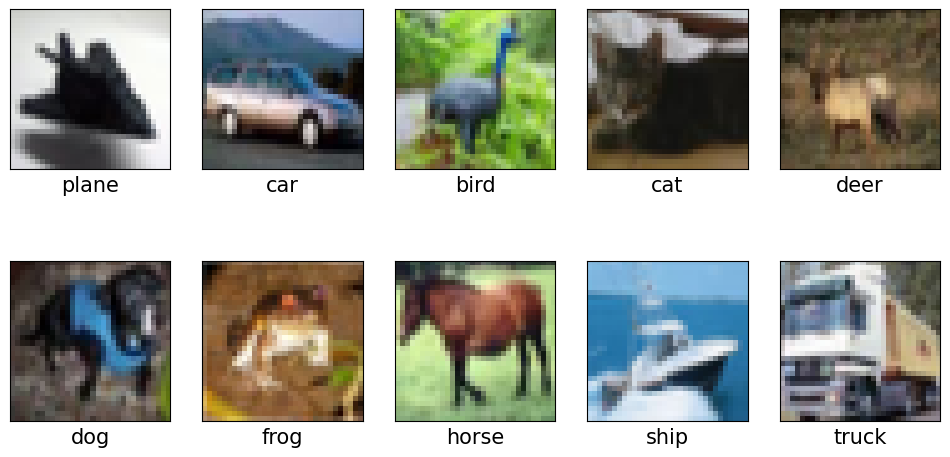

In [6]:
# Visualize training image for each class
sample_images = [train_set.data[np.asarray(train_set.targets) == label][0] for label in range(10)]

# show images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
i = 0
for row in axes:
  for axis in row:
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_xlabel(classes[i], fontsize=15)
    axis.imshow(sample_images[i])
    i += 1


## Define the Model (RegNetY-400MF backbone)

This notebook uses a **RegNetY-400MF** backbone **pretrained on ImageNet** (`IMAGENET1K_V1`) and replaces its classifier head for CIFAR-10 (10 classes). Training runs for **15 epochs** with **full fine-tuning from epoch 1**, so all model parameters are trainable throughout training.

RegNet is a modern convolutional network architecture that incorporates depthwise convolutions, inverted bottlenecks, and BatchNorm normalization, offering strong performance and transfer learning capabilities.

In [7]:
# Use pretrained weights (ImageNet) for RegNetY-400MF
weights = models.RegNet_Y_400MF_Weights.IMAGENET1K_V1
model = models.regnet_y_400mf(weights=weights)

# Replace the classification head for CIFAR-10 (10 output classes)
model.fc = nn.Linear(model.fc.in_features, 10)

# Full fine-tuning from epoch 1
for param in model.parameters():
    param.requires_grad = True

In [8]:
summary(model=model, input_size=(1, 3, 224, 224), col_width=15,
        col_names=['input_size', 'output_size', 'num_params', 'trainable'],
        row_settings=['var_names'], verbose=0)


Layer (type (var_name))                                      Input Shape     Output Shape    Param #         Trainable
RegNet (RegNet)                                              [1, 3, 224, 224] [1, 10]         --              True
├─SimpleStemIN (stem)                                        [1, 3, 224, 224] [1, 32, 112, 112] --              True
│    └─Conv2d (0)                                            [1, 3, 224, 224] [1, 32, 112, 112] 864             True
│    └─BatchNorm2d (1)                                       [1, 32, 112, 112] [1, 32, 112, 112] 64              True
│    └─ReLU (2)                                              [1, 32, 112, 112] [1, 32, 112, 112] --              --
├─Sequential (trunk_output)                                  [1, 32, 112, 112] [1, 440, 7, 7]  --              True
│    └─AnyStage (block1)                                     [1, 32, 112, 112] [1, 48, 56, 56] --              True
│    │    └─ResBottleneckBlock (block1-0)                    [1, 3

## Training the Network

Training is performed in a standard supervised loop with:

- forward pass -> compute logits -> cross-entropy loss
- backward pass -> optimizer step
- metric tracking: training loss + training accuracy

This notebook uses **single-stage full fine-tuning**: all parameters are trainable from **epoch 1** through **epoch 15**.

**Hyperparameters (current configuration):**
- total epochs: **15**
- train batch size: **128**
- learning rate: **1e-4**
- weight decay: **5e-4**
- optimizer: **AdamW**
- scheduler: **CosineAnnealingLR**

Training progress is tracked via training/validation loss and accuracy; the goal is to reduce loss while avoiding overfitting.

In [9]:
# Create a Models folder to store the checkpoints

import os

os.makedirs("Models", exist_ok=True)


## Specify Loss Function and Optimizer
It's recommended that you use cross-entropy loss for classification. If you look at the documentation (linked above), you can see that PyTorch's cross entropy function applies a softmax funtion to the output layer and then calculates the log loss.


In [10]:
EPOCHS = 15
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 5e-4

criterion = nn.CrossEntropyLoss(label_smoothing=0.001)  # Cross-Entropy Loss for multi-class classification

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

# Specify Learning Rate Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [ ]:
best_val_acc = 0.0
best_epoch = 0

# Mixed precision training setup (only enabled on CUDA)
scaler = amp.GradScaler("cuda", enabled=(device == "cuda"))
autocast_enabled = (device == "cuda")

# Training history tracking
loss_hist, acc_hist = [], []            # training loss / acc per epoch
loss_hist_val, acc_hist_val = [], []    # validation loss / acc per epoch

# Enable faster CUDA kernels for fixed-shape CNN workloads.
if device == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")
    model = model.to(device=device, memory_format=torch.channels_last)
    model = torch.compile(model, mode="reduce-overhead")
else:
    model = model.to(device)

print("Training was started.\n")
time_total_start = time.time()

# Helper: format learning rate in full decimal form (no scientific notation)
def format_lr(lr: float) -> str:
    s = f"{lr:.10f}"
    s = s.rstrip("0").rstrip(".")
    if s == "0":
        s = "0.0"
    return s

for epoch in range(1, EPOCHS + 1):
    time_ckpt = time.time()
    print("EPOCH:", epoch, end=" ")

    # Accumulate on device to avoid .item() every step (GPU-CPU sync bottleneck)
    running_loss = torch.tensor(0.0, device=device)
    correct = torch.tensor(0, device=device, dtype=torch.long)

    # Training loop
    model.train()
    for batch_idx, data in enumerate(train_loader):
        batch, labels = data

        if device == "cuda":
            batch = batch.to(device, non_blocking=True, memory_format=torch.channels_last)
        else:
            batch = batch.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # ===== Updated Alternating Flip (vectorized, branch-free) =====
        # Build deterministic pseudo-indices per batch (single-notebook safe on Windows workers).
        idx = torch.arange(labels.size(0), device=device, dtype=torch.long) + batch_idx * train_loader.batch_size
        hash_idx = (idx * 2654435761) % (2 ** 32)  # 32-bit hash

        # Add .view(-1, 1, 1, 1) so the mask broadcasts to image dimensions (N, C, H, W)
        flip_mask = ((hash_idx + epoch) % 2 == 1).view(-1, 1, 1, 1)

        # Flip the entire batch, then use torch.where to select flipped vs non-flipped images
        batch = torch.where(flip_mask, torch.flip(batch, dims=[3]), batch)
        # ===========================================================

        optimizer.zero_grad()  # Clear the gradients

        # Autocast is only enabled on CUDA.
        with autocast(device_type="cuda", enabled=autocast_enabled):
            outputs = model(batch)
            loss = criterion(outputs, labels)

        if device == "cuda":
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        # Compute training statistics (stay on device; no .item() per step)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum()
        running_loss += loss.detach().float()

    avg_loss = (running_loss / len(train_loader)).item()
    avg_acc = correct.item() / len(train_set)
    loss_hist.append(avg_loss)
    acc_hist.append(avg_acc)

    # Validation loop
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        loss_val = torch.tensor(0.0, device=device)
        correct_val = torch.tensor(0, device=device, dtype=torch.long)

        for data in val_loader:
            batch, labels = data

            if device == "cuda":
                batch = batch.to(device, non_blocking=True, memory_format=torch.channels_last)
            else:
                batch = batch.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with autocast(device_type="cuda", enabled=autocast_enabled):
                outputs = model(batch)
                loss = criterion(outputs, labels)

            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum()
            loss_val += loss.float()

        avg_loss_val = (loss_val / len(val_loader)).item()
        avg_acc_val = correct_val.item() / len(val_set)
        loss_hist_val.append(avg_loss_val)
        acc_hist_val.append(avg_acc_val)

    model.train()       # Set the model back to training mode
    scheduler.step()    # Update the learning rate scheduler
    current_lr = optimizer.param_groups[0]["lr"]

    # Track best validation accuracy
    is_best = avg_acc_val > best_val_acc
    if is_best:
        best_val_acc = avg_acc_val
        best_epoch = epoch

    # Save the model at the end of each epoch
    model.eval()
    torch.save(model.state_dict(), f"Models/regnet_model_{epoch}.pth")
    model.train()

    # Print training statistics
    print(f"LR: {format_lr(current_lr)}", end=" ")
    print("Train Loss: {:.4f}".format(avg_loss), end=" ")
    print("Val Loss: {:.4f}".format(avg_loss_val), end=" ")
    print("Train Acc: {:.2f}%".format(avg_acc * 100), end=" ")
    print("Val Acc: {:.2f}%".format(avg_acc_val * 100), end=" ")
    print("Time: {:.2f}s".format(time.time() - time_ckpt), end="")
    if is_best:
        print(" Best!", end="")
    print()  # new line

time_total = time.time() - time_total_start
print(f"\n✓ Training completed! Best val acc: {best_val_acc*100:.2f}% at epoch {best_epoch}")
print("Per-epoch checkpoints saved in Models/regnet_model_{epoch}.pth")
print(f"Total training time: {time_total:.2f}s ({time_total/60:.2f} min)")

Training was started.

EPOCH: 1 

W0316 17:53:02.536000 22594 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


## Plotting Training Statistics

Loss is a function of the difference of the network output and the target values. We are minimizing the loss function during training so it should decrease over time. Accuracy is the classification accuracy for the test data.


In [ ]:
plots=[(loss_hist,loss_hist_val),(acc_hist,acc_hist_val)]
plt_labels=[("Training Loss","Validation Loss"),("Training Accuracy","Validation Accuracy")]
plt_titles=["Loss","Accuracy"]
plt.figure(figsize=(20,7))
for i in range(0,2):
    ax=plt.subplot(1,2,i+1)
    ax.plot(plots[i][0],label=plt_labels[i][0])
    ax.plot(plots[i][1],label=plt_labels[i][1])
    ax.set_title(plt_titles[i])
    ax.legend()


## Save the trained model


In [ ]:
# from google.colab import files
# torch.save(model.state_dict(), 'checkpoint.pth')
# # download checkpoint file
# files.download('checkpoint.pth')
# model.load_state_dict(torch.load('checkpoint.pth'))


In [ ]:
# Selecting the best model
best_acc = max(acc_hist_val)
best_epoch = acc_hist_val.index(best_acc)+1

print("Best accuracy on validation set: {:.2f}%".format(best_acc*100))
print("Best epoch: {}".format(best_epoch))

state_dict = torch.load(
    f"Models/regnet_model_{best_epoch}.pth",
    map_location=device
)

model.load_state_dict(state_dict)
if device == "cuda":
    model = model.to(device=device, memory_format=torch.channels_last)
else:
    model = model.to(device)
model.eval()


# Test the Trained Network
Finally, we test our best model on previously unseen test data and evaluate it's performance. Testing on unseen data is a good way to check that our model generalizes well. It may also be useful to be granular in this analysis and take a look at how this model performs on each class as well as looking at its overall loss and accuracy.


In [ ]:
pred_vec = []
label_vec = []
correct = 0

if device == "cuda":
    model = model.to(device=device, memory_format=torch.channels_last)
else:
    model = model.to(device)
model.eval()

test_loss_sum = 0.0   # accumulate loss * batch_size over all batches
test_samples = 0      # total number of samples

with torch.no_grad():
    for data in test_loader:
        batch, labels = data
        if device == "cuda":
            batch = batch.to(device, non_blocking=True, memory_format=torch.channels_last)
        else:
            batch = batch.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(batch)
        loss = criterion(outputs, labels)

        # accumulate loss for weighted average
        batch_size = labels.size(0)
        test_loss_sum += loss.item() * batch_size
        test_samples += batch_size

        # accumulate correct predictions and store predictions/labels
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        pred_vec.extend(predicted.cpu().numpy())
        label_vec.extend(labels.cpu().numpy())

# compute average loss over the whole test set
test_loss = test_loss_sum / test_samples

pred_vec = np.array(pred_vec)
label_vec = np.array(label_vec)


# Display the Test Set Accuracy


In [ ]:
print("Test Loss: {:.2f}".format(test_loss))
print('Test set Accuracy on the 5,000 test images: %.2f %%' % (100 * correct / len(test_set)))


# Display the Confusion Matrix


In [ ]:
# Create confusion matrix
from sklearn.metrics import confusion_matrix
confusion_mat = confusion_matrix(label_vec, pred_vec)
# Convert confusion matrix to pandas DataFrame
labels = np.unique(label_vec)
confusion_df = pd.DataFrame(confusion_mat, index=classes, columns=classes)
print("Confusion Matrix")
confusion_df


# Compute the Accuracy, F1-Score, Precision, Recall, Support

The table below shows per-class precision, recall, and F1-score as **percentages**, and labels are shown as the CIFAR-10 class names (not numeric indices). The `support` column shows how many test samples belong to each class.


In [ ]:
# Create a report to show the f1-score, precision, recall
from sklearn.metrics import classification_report

report = pd.DataFrame.from_dict(
    classification_report(label_vec, pred_vec, output_dict=True)
).T

# Map numeric class indices back to class names, keep aggregate rows readable
def _format_label(idx: str) -> str:
    if idx.isdigit():
        return classes[int(idx)]
    if idx == "accuracy":
        return "Accuracy"
    if idx == "macro avg":
        return "Macro avg"
    if idx == "weighted avg":
        return "Weighted avg"
    return idx

report["Label"] = report.index.map(_format_label)
report = report[["Label", "precision", "recall", "f1-score", "support"]]

# Show percentages for the metrics to make them easier to interpret
report[["precision", "recall", "f1-score"]] = report[["precision", "recall", "f1-score"]].mul(100).round(2)

report


In [ ]:
from IPython.display import Markdown, display

# Auto-generated summary report (based on variables computed during training + evaluation)
best_val_acc_pct = best_val_acc * 100 if "best_val_acc" in globals() else None
best_epoch_num = best_epoch if "best_epoch" in globals() else None

test_acc = 100 * correct / len(test_set) if "correct" in globals() else None
test_loss_val = test_loss if "test_loss" in globals() else None
training_time_secs = time_total if "time_total" in globals() else None

md_lines = [
    "## Auto-generated Summary Report",
    "",
]

if best_val_acc_pct is not None and best_epoch_num is not None:
    md_lines.append(f"**Best validation accuracy:** {best_val_acc_pct:.2f}% (epoch {best_epoch_num})")
if test_acc is not None:
    md_lines.append(f"**Test accuracy:** {test_acc:.2f}%")
if test_loss_val is not None:
    md_lines.append(f"**Test loss:** {test_loss_val:.4f}")
if training_time_secs is not None:
    md_lines.append(f"**Total training time:** {training_time_secs:.1f}s")

md_lines.append("")
md_lines.append("### Per-class metrics (test set)")

md = "\n".join(md_lines)

display(Markdown(md))
display(report)


In the context of classification, 'support' refers to the number of instances or samples in a dataset that belong to a specific class. It represents the frequency or count of occurrences of each class in the dataset.

Support values help assess the reliability and generalizability of classification models, as they indicate the amount of data available for each class and the potential challenges associated with imbalanced datasets.


# Visualize Sample Test Results
This cell displays test images and their labels in this format: predicted (ground-truth). The text will be green for accurately classified examples and red for incorrect predictions.


In [ ]:
# obtain one batch of test images
images, labels = next(iter(test_loader))
# Keep model on device (torch.compile does not support .cpu()). Run inference on device.
images = images.to(device)
with torch.no_grad():
    output = model(images)
# convert output probabilities to predicted class
_, preds = torch.max(output, 1)
images, preds = images.cpu(), preds.cpu()  # move to CPU for plotting

# Create a 4x4 grid for displaying the images
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

# Iterate over the images and display them in the grid
for idx, ax in enumerate(axes.flat):
  # Normalize the image tensor to [0, 1] range
  image = images[idx].permute(1, 2, 0)
  image = (image - image.min()) / (image.max() - image.min())
  ax.imshow(image)  # Display the image
  ax.axis('off')  # Hide the axes
  ax.set_title("{}".format(classes[preds[idx]]),
                 color=("green" if preds[idx]==labels[idx] else "red"))  # Add title to the image
plt.show()


# Display 50 Predicted Images

This cell displays 50 test images with the model’s predicted label:

- **Green label:** prediction is correct
- **Red label:** prediction is incorrect

Use this view to inspect model mistakes and identify common confusion patterns (e.g., cat vs dog, ship vs plane).

In [ ]:
# Define the loader for all test data
test_set_all = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=test_transform)
test_loader_all = torch.utils.data.DataLoader(test_set_all, batch_size=192, shuffle=False, num_workers=4)

# obtain one batch of test images
dataiter = iter(test_loader_all)
images, labels = next(dataiter)
model.to(device)
images = images.to(device)
labels = labels.to(device)

# get sample outputs
with torch.no_grad():
    output = model(images)
# convert output probabilities to predicted class
_, preds = torch.max(output, 1)
images, preds, labels = images.cpu(), preds.cpu(), labels.cpu()  # for matplotlib

fig = plt.figure(figsize=(15, 7))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for idx in range(50):
    # Normalize the image tensor to [0, 1] range
    image = images[idx].permute(1, 2, 0)
    image = (image - image.min()) / (image.max() - image.min())
    ax = fig.add_subplot(5, 10, idx + 1, xticks=[], yticks=[])
    ax.imshow(image, interpolation='nearest')

    if preds[idx]==labels[idx]:
      ax.text(0, 3, str(classes[preds[idx].item()]), color='green')
    else:
      ax.text(0, 3, str(classes[preds[idx].item()]), color='red')

plt.show()


## Visualize wrongly classified image for each class


In [ ]:
# Visualize wrongly classified image for each class
pred_vec_all = []
correct = 0
test_loss = 0.0

if device == "cuda":
    model = model.to(device=device, memory_format=torch.channels_last)
else:
    model = model.to(device)

with torch.no_grad():
    for data in test_loader_all:
        batch, labels = data
        if device == "cuda":
            batch = batch.to(device, memory_format=torch.channels_last)
        else:
            batch = batch.to(device)
        labels = labels.to(device)
        outputs = model(batch)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        pred_vec_all.append(predicted)
    pred_vec_all = torch.cat(pred_vec_all)

pred_vec_all = pred_vec_all.cpu().numpy()
ground_truths = np.asarray(test_set_all.targets)
incorrect_mask = pred_vec_all != ground_truths
# One (wrong if any, else any) sample per class to avoid IndexError when a class has no errors
incorrect_images = []
pred_results_all = []
for label in range(10):
    wrong_mask = (ground_truths == label) & incorrect_mask
    if wrong_mask.any():
        idx = np.where(wrong_mask)[0][0]
        incorrect_images.append(test_set_all.data[idx])
        pred_results_all.append(pred_vec_all[idx])
    else:
        idx = np.where(ground_truths == label)[0][0]
        incorrect_images.append(test_set_all.data[idx])
        pred_results_all.append(pred_vec_all[idx])

# show images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
i = 0
for row in axes:
  for axis in row:
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_xlabel("Predicted: %s" % classes[pred_results_all[i]], fontsize=10)
    axis.imshow(incorrect_images[i], cmap='gray')
    i += 1
